<a href="https://colab.research.google.com/github/KhannakPGupta/Bike-Rental-Analysis/blob/main/SRM_Insider_Bike_Rental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Cell used to install all the files
!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot

In [ ]:
#Cell to fetch the file so that it gets redownloaded on it
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
!unzip -q Bike-Sharing-Dataset.zip
import pandas as pd
df = pd.read_csv('hour.csv')
df.head()

replace Readme.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
#Cell to preprocess all the data
df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

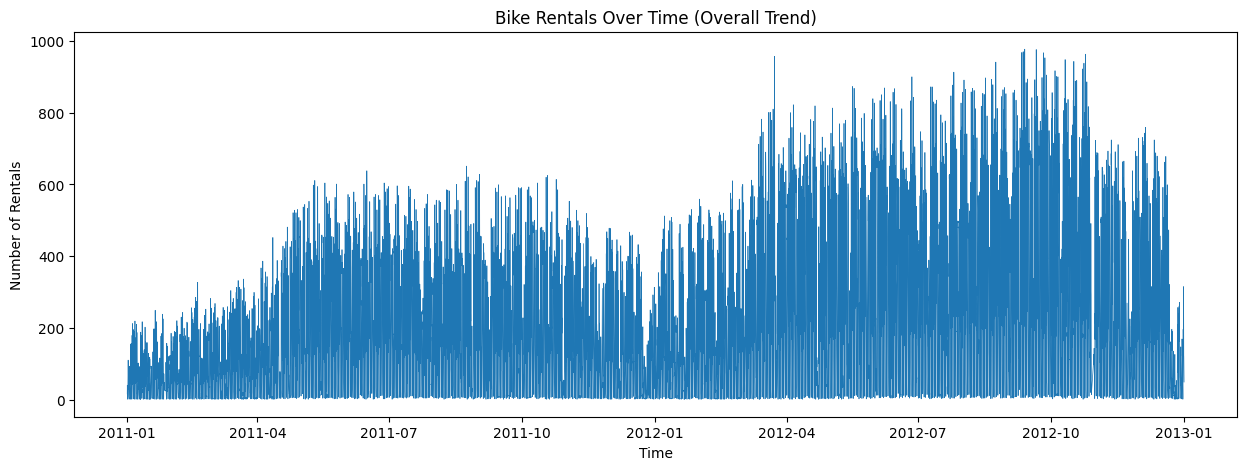

In [ ]:
#Cell to represent trends
plt.figure(figsize=(15,5))
plt.plot(df['cnt'], linewidth=0.5)
plt.title("Bike Rentals Over Time (Overall Trend)")
plt.xlabel("Time")
plt.ylabel("Number of Rentals")
plt.show()

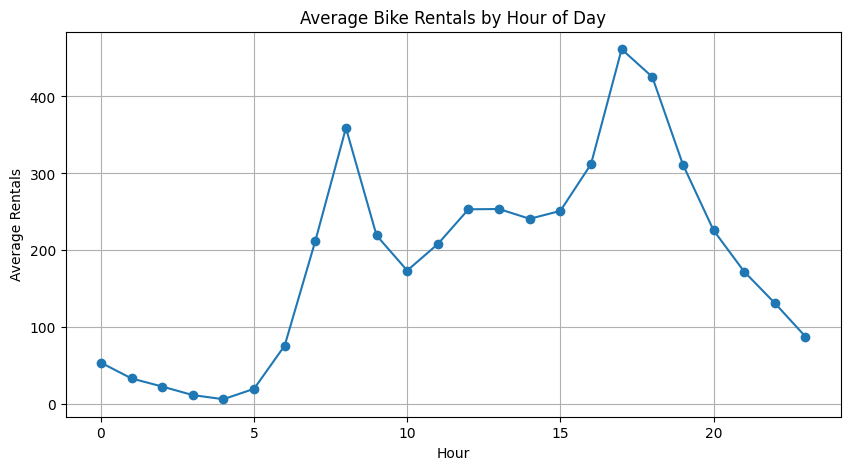

In [ ]:
#Cell to represent hourly patterns
hourly_avg = df.groupby(df.index.hour)['cnt'].mean()
plt.figure(figsize=(10,5))
plt.plot(hourly_avg, marker='o')
plt.title("Average Bike Rentals by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()

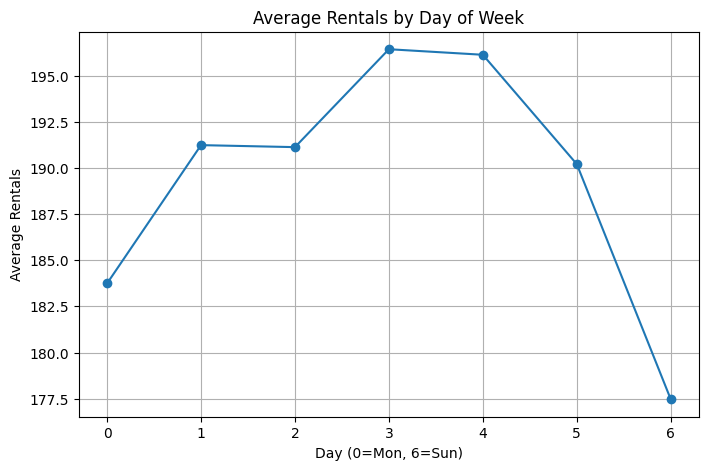

In [ ]:
#Cell to represent daily patterns
daily_avg = df.groupby(df.index.dayofweek)['cnt'].mean()
plt.figure(figsize=(8,5))
plt.plot(daily_avg, marker='o')
plt.title("Average Rentals by Day of Week")
plt.xlabel("Day (0=Mon, 6=Sun)")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()

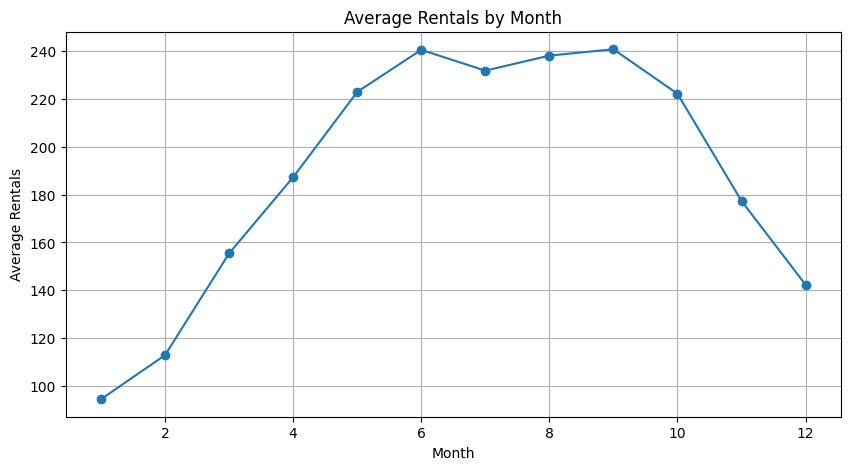

In [ ]:
#Cell to represent monthly patterns
monthly_avg = df.groupby(df.index.month)['cnt'].mean()
plt.figure(figsize=(10,5))
plt.plot(monthly_avg, marker='o')
plt.title("Average Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()

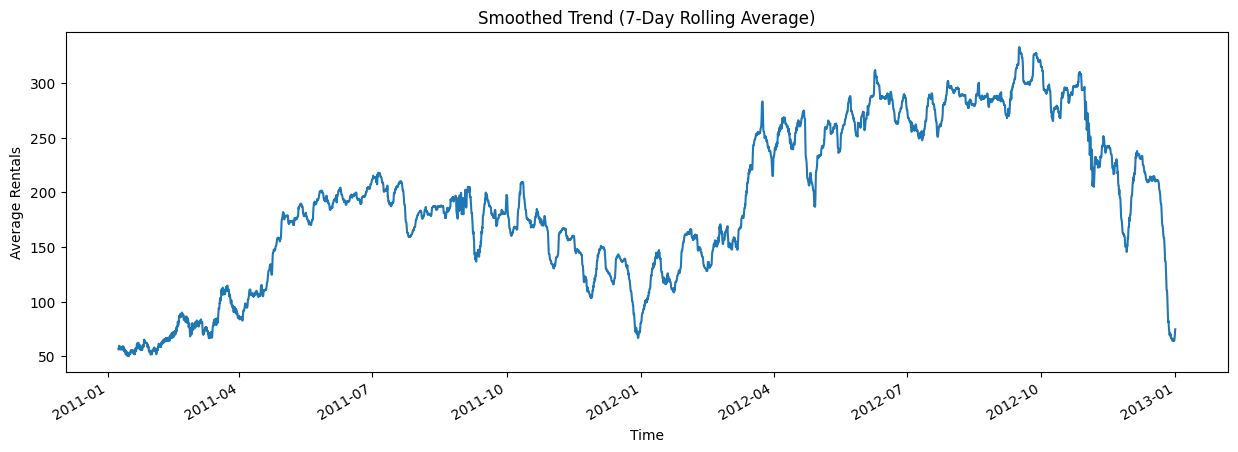

In [ ]:
#Cell to represent smoothed seasonal trends since last one was too noisy
plt.figure(figsize=(15,5))
df['cnt'].rolling(window=168).mean().plot()
plt.title("Smoothed Trend (7-Day Rolling Average)")
plt.xlabel("Time")
plt.ylabel("Average Rentals")
plt.show()

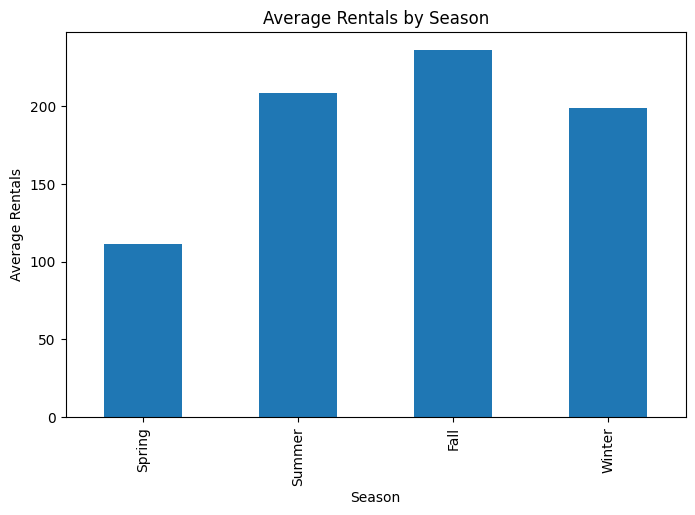

In [ ]:
#Cell to represent seasonal patterns
season_map = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
seasonal_avg = df.groupby('season')['cnt'].mean()
seasonal_avg.index = seasonal_avg.index.map(season_map)
seasonal_avg.plot(kind='bar', figsize=(8,5))
plt.title("Average Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()

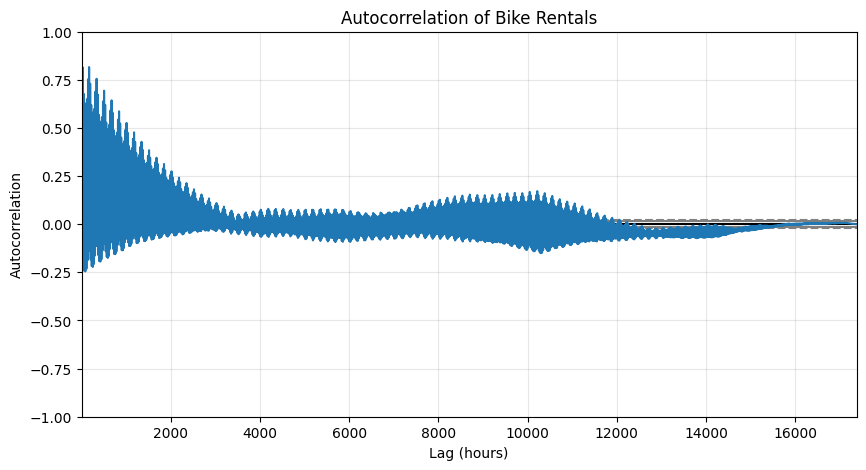

In [ ]:
#Cell for autocorrelation
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
autocorrelation_plot(df['cnt'])
plt.title("Autocorrelation of Bike Rentals")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()

Number of anomalies: 55


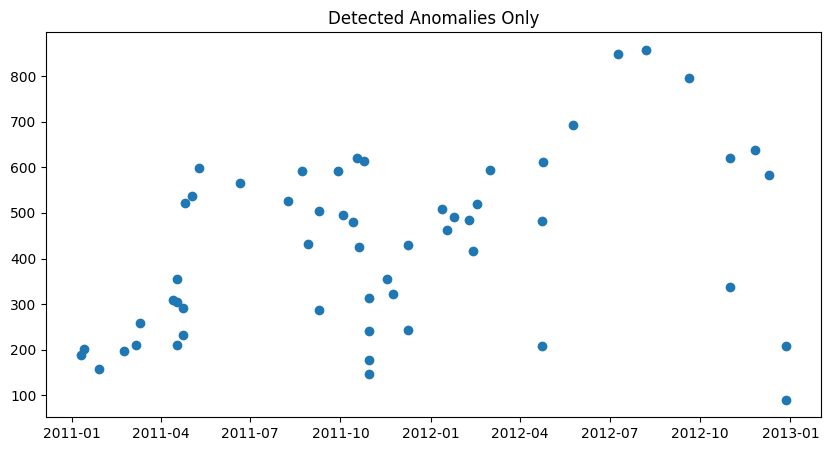

In [ ]:
#Cell for anomaly detection
window = 24  # 24 hours (daily cycle)
df['rolling_mean'] = df['cnt'].rolling(window).mean()
df['rolling_std'] = df['cnt'].rolling(window).std()
df['z_score'] = (df['cnt'] - df['rolling_mean']) / df['rolling_std']
threshold = 3
anomalies = df[np.abs(df['z_score']) > threshold]
print("Number of anomalies:", len(anomalies))
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(anomalies.index, anomalies['cnt'])
plt.title("Detected Anomalies Only")
plt.show()

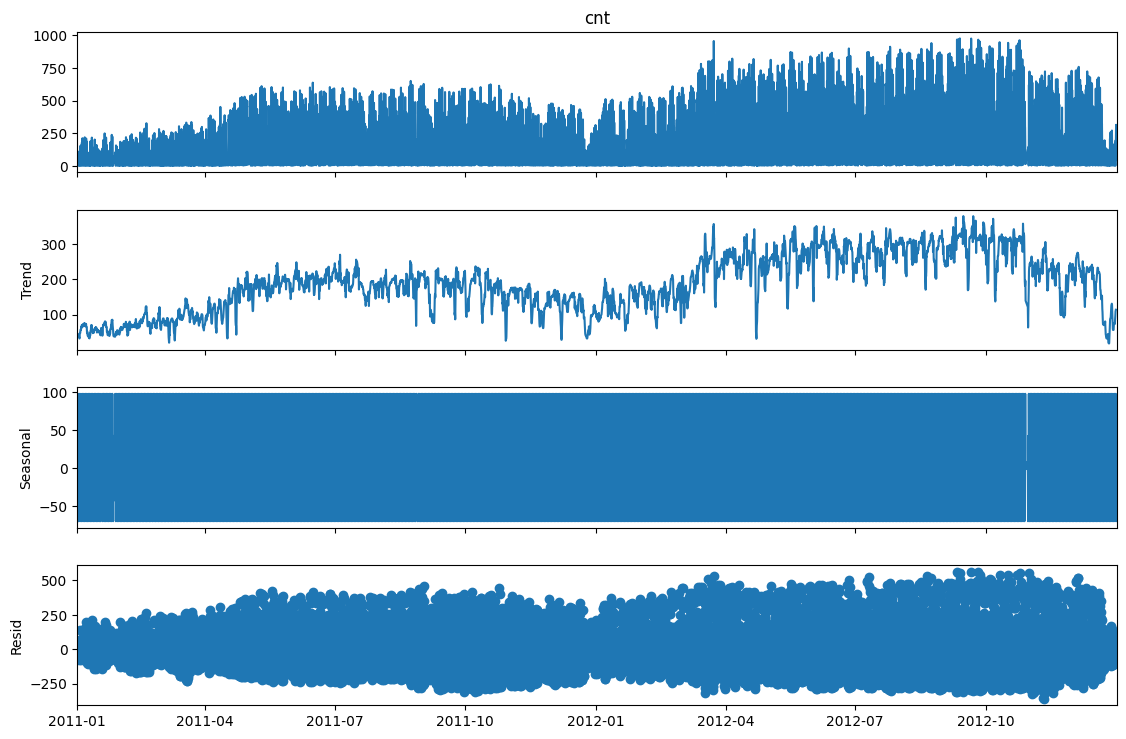

In [ ]:
#Cell for decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
ts = df['cnt'].dropna()
decomp = seasonal_decompose(ts, model='additive', period=24)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

In [ ]:
#Cell for train-test splitting
X = df.drop('cnt', axis=1)
y = df['cnt']
split = int(len(df)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
#Cell for training the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#Cell for prediction
y_pred = model.predict(X_test)

In [ ]:
#Cell for evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6.65662830840046
RMSE: 11.505157801674297


In [ ]:
#Cell to create baseline
baseline_pred = y_test.shift(1).fillna(method='bfill')
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 85.16225546605294
Baseline RMSE: 129.6472841863376


/tmp/ipykernel_330/2598392428.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  baseline_pred = y_test.shift(1).fillna(method='bfill')


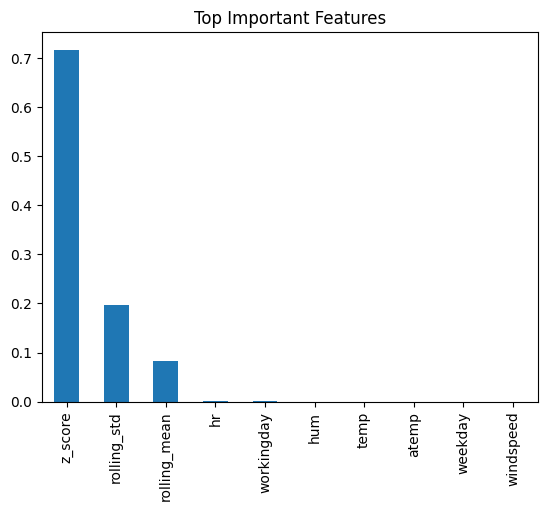

In [ ]:
#Cell for feature engineering
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['lag_1'] = df['cnt'].shift(1)
df['lag_24'] = df['cnt'].shift(24)
df['lag_168'] = df['cnt'].shift(168)
df['rolling_mean_24'] = df['cnt'].rolling(24).mean()
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df.dropna(inplace=True)
import pandas as pd
importance = model.feature_importances_
features = X.columns
feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
feat_imp.head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()

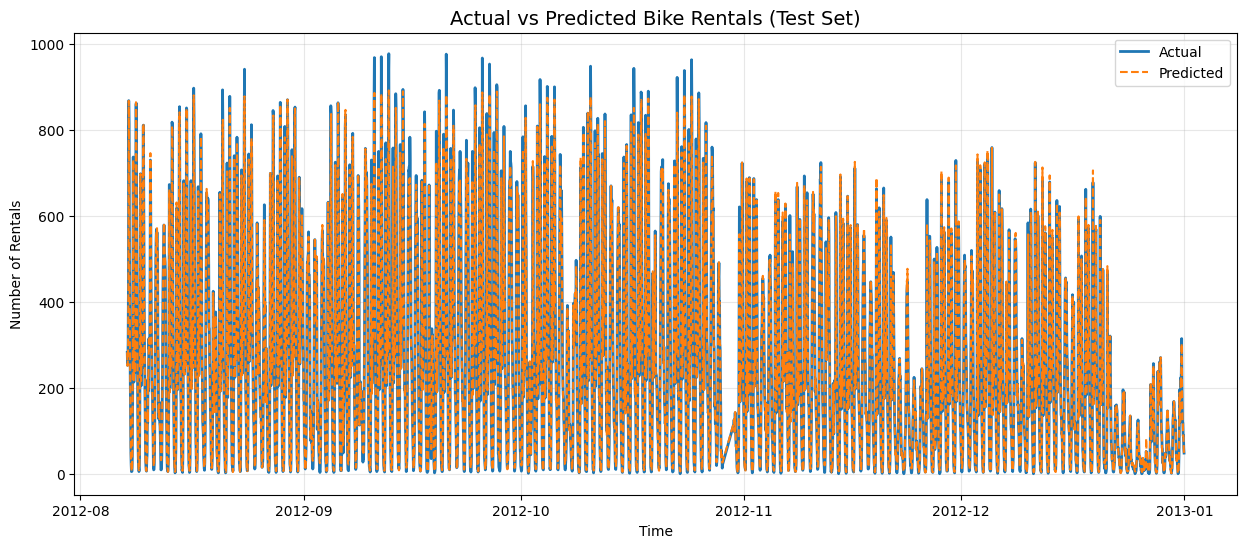

In [ ]:
#Cell for the final plot
plt.figure(figsize=(15,6))
plt.plot(y_test.index, y_test.values, label='Actual', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted', linestyle='--')
plt.title("Actual vs Predicted Bike Rentals (Test Set)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Number of Rentals")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

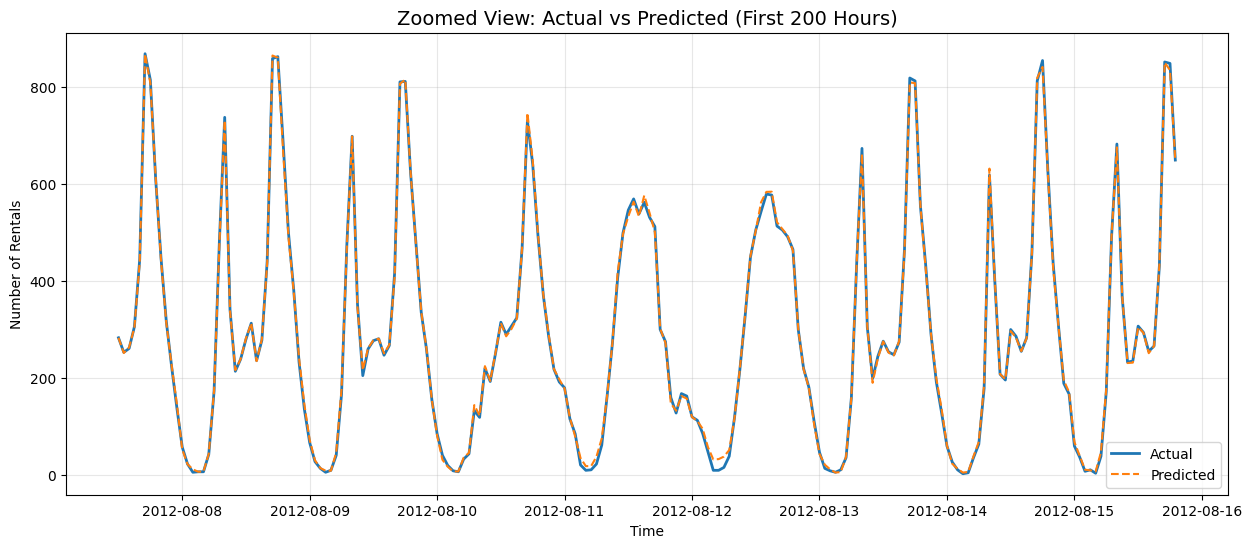

In [ ]:
#Cell for zoomed in final plot for better visualisation
plt.figure(figsize=(15,6))
#Only first 200 points
plt.plot(y_test.index[:200], y_test.values[:200], label='Actual', linewidth=2)
plt.plot(y_test.index[:200], y_pred[:200], label='Predicted', linestyle='--')
plt.title("Zoomed View: Actual vs Predicted (First 200 Hours)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Number of Rentals")
plt.grid(alpha=0.3)
plt.legend()
plt.show()